In [1]:
#LOADING MAIN LIBRARIES
import xarray as xr
import numpy as np
import matplotlib
matplotlib.use("Agg") #figures are not sent to the Jupyter frontend #*#* (turn off if wanting to see plots in Notebook)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from tqdm import tqdm

import os

In [2]:
#SETTING UP MAIN DIRECTORIES
mainDirectory = "/glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/"

In [3]:
#DIRECTORY FUNCTIONS
def ListFiles(directory, n=10):
    files = os.listdir(directory)
    # print("Listing first", n, "files:\n", files[:n], "\n")
    return files

In [4]:
#LOADING CLASSES
# --- Add your Functions folder to sys.path ---
import sys
path = mainDirectory + '/Functions_2.0/Classes'
sys.path.append(path)

# --- Import all your function modules ---
import importlib
modules = [
    "Classes_MapPlotting"
]

for mod in modules:
    globals()[mod] = importlib.import_module(mod)        # import module itself
    globals().update(vars(globals()[mod]))              # import all functions into global namespace

In [5]:
################################################################################

In [6]:
#DATA DESCRIPTIONS

### Data Type
# MicroPulse Differential Absorption Lidar (MPD)

### DOI (Permanent Link)
# https://doi.org/10.26023/QA4M-CDHH-MY0Z

### Summary
# MicroPulse Differential Absorption Lidar (MPD) data 
# in NetCDF format which were collected during the 
# Prediction of Rainfall Extremes Campaign In the Pacific (PRECIP). 
# Three MPDs were deployed to Taiwan for this field project.

### Temporal Coverage
# Begin datetime	2022-05-25 00:00:00
# End datetime	2022-08-11 02:59:59

### Spatial Coverage
# Maximum (North) Latitude: 27.50, Minimum (South) Latitude: 22.50
# Minimum (West) Longitude: 118.00, Maximum (East) Longitude: 123.50

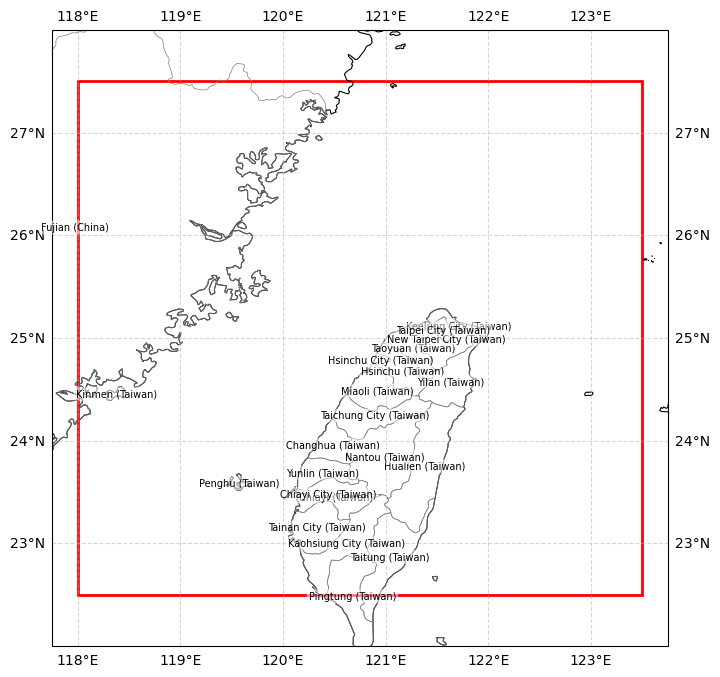

In [7]:
mapPlotting = MapPlotting(
    sw_corner=(22.50, 118.00),  # (lat_min, lon_min)
    ne_corner=(27.50, 123.50),  # (lat_max, lon_max)
    delta=3,
    fontsize=7
)
mapPlotting.PlotBoundingBox()

In [8]:
################################################################################

In [9]:
#SET UP DIRECTORIES
Campaign="PRECIP"
DataType="NCAR_SPol_RadarMoments_Data"

#Code Directory
Code_Directory="/glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/DataAnalysis/Observation_Data"
Code_Directory=os.path.join(Code_Directory,Campaign)
print("Code Directory Set as:", Code_Directory, '\n')

def GetDataDirectory(Campaign, Downloaded_File,
                     DataType="NCAR_SPol_RadarMoments_Data",
                     BaseDir="/glade/work/aroseman/Projects/Regional-MPAS-Project/Code/DATA/Observation_Data"):
    #old base directory: BaseDir="/glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/Code/DATA/Observation_Data"
    SurDir = os.path.join(BaseDir, Campaign, DataType, Downloaded_File, "unzip", "sur")
    Date = os.listdir(SurDir)[0]
    Data_Directory = os.path.join(SurDir, Date)
    print("Data Directory Set as:", Data_Directory, '\n')
    FileList = ListFiles(Data_Directory)
    return Data_Directory, FileList
# Downloaded_File="abrah3490212"
# Data_Directory, FileList=GetDataDirectory(Campaign, Downloaded_File, Date)

#Output Directory
Output_Directory="/glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT/DataAnalysis/Observation_Data"
Output_Directory=os.path.join(Output_Directory,Campaign,DataType)

Code Directory Set as: /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/DataAnalysis/Observation_Data/PRECIP 



In [10]:
#READING DATA
###################################
#how to unzip in terminal
# mkdir -p unzip
# for f in *.tar; do
#     tar -xvf "$f" -C unzip
# done

In [11]:
def GetData(Data_Directory, FileList, index):
    DataFile = os.path.join(Data_Directory,FileList[index])
    # print(f"Downloading File:\n {DataFile}","\n")
    DataNC = xr.open_dataset(DataFile,decode_timedelta=True)
    return DataNC, DataFile

In [ ]:
#TESTING 3D interpolation of radar data

In [43]:
ds['DBZ']

<xarray.DataArray 'DBZ' (n_points: 9595200)> Size: 38MB
[9595200 values with dtype=float32]
Dimensions without coordinates: n_points
Attributes:
    long_name:       DBZ
    standard_name:   DBZ
    units:           dBZ
    sampling_ratio:  1.0
    grid_mapping:    grid_mapping

In [34]:
Downloaded_Files = [
    "abrah3490212", "abrah3490427", "abrah3490662", "abrah3490787",
    "abrah3490851", "abrah3490958", "abrah3491051", "abrah3491164",
    "abrah3491407", "abrah3491539", "abrah3491655", "abrah3491774",
    "abrah3492007", "abrah3538738", "abrah3545842", "abrah3546228",
    "abrah3547913", "abrah3548220", "abrah3548825",
]
Data_Directory, FileList = GetDataDirectory(Campaign, Downloaded_Files[0])
index=0
DataFile = os.path.join(Data_Directory,FileList[index])
ds=DataNC = xr.open_dataset(DataFile,decode_timedelta=True)
ds.data_vars



Data Directory Set as: /glade/work/aroseman/Projects/Regional-MPAS-Project/Code/DATA/Observation_Data/PRECIP/NCAR_SPol_RadarMoments_Data/abrah3490212/unzip/sur/20220527 



In [35]:
import pyart
radar = pyart.io.read_cfradial(DataFile)

radar.add_field_like('DBZ', 'reflectivity', radar.fields['DBZ']['data'], replace_existing=True)
print(radar.fields.keys())

dict_keys(['RATE_ZH', 'RATE_HYBRID', 'PID', 'TEMP_FOR_PID', 'DBZ', 'DBZ_F', 'VEL', 'VEL_F', 'WIDTH', 'WIDTH_F', 'NCP', 'NCP_F', 'ZDR_F', 'PHIDP_F', 'KDP_F', 'RHOHV_F', 'RHOHV_NNC_F', 'SNRHC', 'SNRHC_F', 'SNRVC', 'SNRVC_F', 'DBMHC', 'DBMHC_F', 'DBMVC', 'DBMVC_F', 'CMD_FLAG', 'reflectivity'])


In [36]:
import numpy as np

# 1 km horizontal resolution, 0.5 km vertical
nx, ny, nz = 200, 200, 40
dx, dy, dz = 1000., 1000., 500.  # meters
xlim = (-100000., 100000.)   # -100 to +100 km
ylim = (-100000., 100000.)
zlim = (0., dz*(nz-1))

grid = pyart.map.grid_from_radars(
    radar,
    grid_shape=(nz, ny, nx),
    grid_limits=(zlim, ylim, xlim),
    fields=['reflectivity'],
    weighting_function='CRESSMAN',
    roi_func='constant',  # or custom function
    constant_roi=1500.0   # radius of influence in meters
)


In [37]:
dbz_grid = grid.fields['reflectivity']['data']  # shape (nz, ny, nx)
z = grid.z['data']   # vertical levels (m)
y = grid.y['data']   # east-west
x = grid.x['data']   # north-south


Text(0.5, 1.0, 'S-Pol Reflectivity at 2 km')

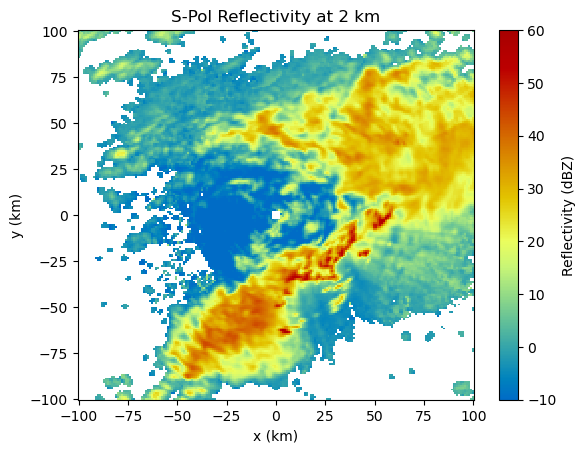

In [38]:
import matplotlib.pyplot as plt

level = np.argmin(np.abs(z - 2000.))  # nearest to 2 km
dbz_slice = dbz_grid[level, :, :].filled(np.nan)
plt.pcolormesh(x/1000, y/1000, dbz_slice,
               cmap=cmap_reflectivity, vmin=-10, vmax=60)
plt.colorbar(label='Reflectivity (dBZ)')
plt.xlabel('x (km)')
plt.ylabel('y (km)')
plt.title('S-Pol Reflectivity at 2 km')

Max dBZ at 64.0 dBZ, x=52.8 km, y=-2.5 km, z=0.5 km


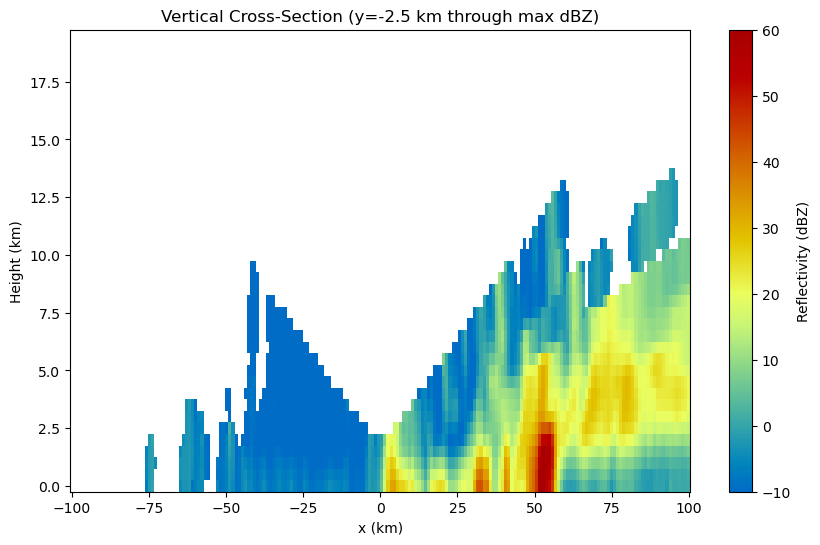

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Find the location of maximum reflectivity ---
dbz_filled = dbz_grid.filled(np.nan)
imax = np.nanargmax(dbz_filled)
k, j, i = np.unravel_index(imax, dbz_filled.shape)

x_max = x[i] / 1000.0  # km
y_max = y[j] / 1000.0
z_max = z[k] / 1000.0
print(f"Max dBZ at {dbz_filled[k,j,i]:.1f} dBZ, "
      f"x={x_max:.1f} km, y={y_max:.1f} km, z={z_max:.1f} km")

# --- 2. Choose a cross-section orientation ---
# Example A: West–East slice at y = y_max
cross_section = dbz_filled[:, j, :]   # shape (nz, nx)

# --- 3. Plot ---
X, Z = np.meshgrid(x/1000.0, z/1000.0, indexing="xy")

plt.figure(figsize=(10,6))
plt.pcolormesh(X, Z, cross_section, cmap=cmap_reflectivity,
               vmin=-10, vmax=60, shading="auto")
plt.colorbar(label="Reflectivity (dBZ)")
plt.xlabel("x (km)")
plt.ylabel("Height (km)")
plt.title(f"Vertical Cross-Section (y={y_max:.1f} km through max dBZ)")
plt.show()


In [22]:
# PLOTTING FUNCTIONS
###################################

In [23]:
#GETTING COLORMAPS

# The Python ARM Radar Toolkit - Py-ART
# git clone https://github.com/ProjectPythia/radar-cookbook.git
# pip install arm_pyart
import pyart

import inspect
print(inspect.getsource(pyart.config.get_field_colormap))
print(pyart.config._DEFAULT_FIELD_COLORMAP.keys())


cmap_reflectivity = pyart.config.get_field_colormap('reflectivity')
# cmap_dBZ = pyart.config.get_field_colormap('dBZ') #same as reflectivity
# cmap_dbz = pyart.config.get_field_colormap('dbz') #same as reflectivity
# cmap_DBZ = pyart.config.get_field_colormap('DBZ') #same as reflectivity
cmap_viridis = plt.cm.viridis
cmap_velocity = pyart.config.get_field_colormap('velocity')
cmap_inferno = plt.cm.inferno
# import matplotlib.cm as cm
# cmap = cm.get_cmap(cmap_reflectivity)
# cmap

def get_field_colormap(field):
    """
    Return the colormap name from the configuration file for a field name.
    """
    if field in _DEFAULT_FIELD_COLORMAP:
        return _DEFAULT_FIELD_COLORMAP[field]
    else:
        import matplotlib

        # Use the default matplotlib colormap
        return matplotlib.colormaps.get_cmap("Spectral_r").name

dict_keys(['reflectivity', 'corrected_reflectivity', 'total_power', 'signal_to_noise_ratio', 'velocity', 'corrected_velocity', 'simulated_velocity', 'eastward_wind_component', 'northward_wind_component', 'vertical_wind_component', 'spectrum_width', 'normalized_coherent_power', 'differential_reflectivity', 'corrected_differential_reflectivity', 'clutter_filter_power_removed', 'cross_correlation_ratio', 'logarithmic_cross_correlation_ratio', 'differential_phase', 'unfolded_differential_phase', 'corrected_differential_phase', 'specific_differential_phase', 'corrected_specific_differential_phase', 'linear_polarization_ratio', 'linear_depol

In [24]:
### CLASSES

import os
import re
import numpy as np

class RadarScan:
    def __init__(self, data_directory, file_list, index=1):
        self.DataNC, self.DataFile = GetData(data_directory, file_list, index)
        self.DataName = os.path.basename(self.DataFile)
        
        self.DataDate = self._extract_date_from_filename(self.DataName)
        self.TimeRange = self._extract_time_range_from_filename(self.DataName)
        self.TimeTitle = self._format_time_title("start")

        self._extract_metadata()
        self._extract_variables()
        self._compute_cartesian()
        self._compute_latlon()

        # Close the NetCDF file now that all arrays are pulled out
        self.DataNC.close()

    def _extract_date_from_filename(self, filename):
        """
        Extracts first date string (YYYYMMDD) from a filename.
        """
        match = re.search(r'\d{8}', filename)
        return match.group(0) if match else None

    def _extract_time_range_from_filename(self, filename):
        """
        Extracts start and end times (YYYYMMDD_HH:MM:SS.sss) from radar filename.
    
        Returns
        -------
        (start_time_str, end_time_str) : tuple of str
            Start and end times as strings with full date included.
        """
        # Example match: 20220528_153012.345
        matches = re.findall(r'(\d{8})_(\d{2})(\d{2})(\d{2})\.(\d{3})', filename)
    
        if len(matches) >= 2:
            # Build strings like YYYYMMDD_HH:MM:SS.sss
            start = f"{matches[0][0]}_{matches[0][1]}:{matches[0][2]}:{matches[0][3]}.{matches[0][4]}"
            end   = f"{matches[1][0]}_{matches[1][1]}:{matches[1][2]}:{matches[1][3]}.{matches[1][4]}"
            return start, end
        return None, None
        
        if len(matches) == 2:
            start = f"{matches[0][0]}:{matches[0][1]}:{matches[0][2]}.{matches[0][3]}"
            end   = f"{matches[1][0]}:{matches[1][1]}:{matches[1][2]}.{matches[1][3]}"
            return start, end
        
        return None, None

    def _format_time_title(self, which="start"):
        from datetime import datetime
        if not self.TimeRange or not self.TimeRange[0]:
            return "Time Unknown"

        tstr = self.TimeRange[0] if which == "start" else self.TimeRange[1]

        try:
            dt = datetime.strptime(tstr, "%Y%m%d_%H:%M:%S.%f")
            return dt.strftime("%Y/%m/%d %H:%M:%S UTC")
        except ValueError:
            return tstr

    def _extract_metadata(self):
        self.radar_longitude = self.DataNC['longitude'].values
        self.radar_latitude = self.DataNC['latitude'].values
        self.nt = self.DataNC.sizes['time']
        self.nr = self.DataNC.sizes['range']
        self.times = self.DataNC['time']
        self.azimuths = self.DataNC['azimuth'].values
        self.ranges = (
            self.DataNC['ray_start_range'][0].values +
            np.arange(self.nr) * self.DataNC['ray_gate_spacing'][0].values
        )

    def _extract_variables(self):
        self.dbz = self.DataNC['DBZ'].values.reshape(self.nt, self.nr)
        self.vel = self.DataNC['VEL'].values.reshape(self.nt, self.nr)

    def _compute_cartesian(self):
        r, theta = np.meshgrid(self.ranges, np.deg2rad(self.azimuths))
        self.x = r * np.sin(theta)  # east-west
        self.y = r * np.cos(theta)  # north-south

    def _compute_latlon(self):
        R = 6.371e6  # Earth radius in meters
        dLat = (self.y / R) * (180 / np.pi)
        dLon = (self.x / (R * np.cos(np.deg2rad(self.radar_latitude)))) * (180 / np.pi)

        self.Latitude = self.radar_latitude + dLat
        self.Longitude = self.radar_longitude + dLon

    def summary(self):
        print(f"Radar file: {self.DataName}")
        print(f"Radar date: {self.DataDate}")
        print(f"Time range: {self.TimeRange[0]} to {self.TimeRange[1]}")
        print(f"Radar location: ({self.radar_latitude:.4f}, {self.radar_longitude:.4f})")
        print(f"Shape of reflectivity (dbz): {self.dbz.shape}")
        print(f"Computed lat/lon grid: {self.Latitude.shape}")


In [25]:
def GetSavePath(DataDate, OutputFolder, StartTime, EndTime):
    
    # Convert StartTime and EndTime to safe filename strings
    def clean_time(t): return t.replace(":", "_")
    
    StartTime_clean = clean_time(StartTime)  # e.g., "203646127"
    EndTime_clean = clean_time(EndTime)      # e.g., "204246399"
    
    # Build output path
    OutputName = f"{StartTime_clean}_to_{EndTime_clean}.jpg"
    SavePath = os.path.join(Output_Directory, OutputFolder, DataDate)

    return SavePath, OutputName

In [26]:
### PlotRadarReflectivity
import os
import matplotlib.pyplot as plt

def PlotRadarReflectivity(Latitude, Longitude, dbz,
                          radar_latitude, radar_longitude,
                          cmap_reflectivity, plotter,
                          StartTime, EndTime,
                          DataDate,
                          TimeTitle,
                          OutputFolder="RadarReflectivity"):
    """
    Plot radar reflectivity on a normal matplotlib Axes (not Cartopy) and save the figure.

    Parameters
    ----------
    Latitude : ndarray
        1D or 2D array of latitudes for the data grid.
    Longitude : ndarray
        1D or 2D array of longitudes for the data grid.
    dbz : ndarray
        2D array of radar reflectivity values (dBZ).
    radar_latitude : float
        Latitude of the radar location.
    radar_longitude : float
        Longitude of the radar location.
    cmap_reflectivity : Colormap
        Matplotlib colormap for reflectivity plotting.
    plotter : MapPlotting
        Instance of MapPlotting class for setting up the map.
    StartTime : str
        Start time string to include in filename.
    EndTime : str
        End time string to include in filename.
    OutputFolder : str, optional
        Folder where the figure will be saved (default: "RadarReflectivity").

    Returns
    -------
    FullOutputFile : str
        Path to the saved output file.
    """

    # Plot map from lat/lon bounds
    fig, ax = plotter.PlotFromBounds(
        lat_min=Latitude.min(), lat_max=Latitude.max(),
        lon_min=Longitude.min(), lon_max=Longitude.max()
    )

    # Plot reflectivity
    cs = ax.contourf(Longitude, Latitude, dbz, cmap=cmap_reflectivity)
    plt.colorbar(cs, ax=ax, label="Reflectivity (dBZ)")

    # Axis labels and aspect ratio
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_aspect("equal")

    # Radar location
    ax.plot(radar_longitude, radar_latitude, "o", color="black", markersize=12)
    ax.set_title(TimeTitle, fontsize=18, fontweight="bold")

    # Save figure
    SavePath, OutputName = GetSavePath(DataDate=DataDate, OutputFolder=OutputFolder,
                                       StartTime=StartTime, EndTime=EndTime)
    os.makedirs(SavePath, exist_ok=True)
    FullOutputFile = os.path.join(SavePath, OutputName)
    plt.savefig(FullOutputFile, dpi=150, bbox_inches="tight")
    plt.close(fig)

    print(f"Saved figure to: {FullOutputFile}")
    return FullOutputFile


In [27]:
### PlotRadarVelocity

import os
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

def PlotRadarVelocity(Latitude, Longitude, vel,
                          radar_latitude, radar_longitude,
                          cmap_reflectivity, plotter,
                          StartTime, EndTime,
                          DataDate,
                          TimeTitle,
                          OutputFolder="RadialVelocity"):

    """
    Plot radar radial velocity on a map and save the figure.

    Parameters
    ----------
    Latitude : ndarray
        1D or 2D array of latitudes for the data grid.
    Longitude : ndarray
        1D or 2D array of longitudes for the data grid.
    vel : ndarray
        2D array of radial velocity values (m/s).
    radar_latitude : float
        Latitude of the radar location.
    radar_longitude : float
        Longitude of the radar location.
    cmap_velocity : Colormap
        Matplotlib colormap to use for velocity plotting.
    plotter : MapPlotting
        Instance of MapPlotting class for setting up the map.
    OutputFolder : str, optional
        Name of the folder where the figure will be saved (default is "RadialVelocity").

    Returns
    -------
    FullOutputFile : str
        Path to the saved output file.
    """

    # Plot map from lat/lon bounds
    fig, ax = plotter.PlotFromBounds(
        lat_min=Latitude.min(), lat_max=Latitude.max(),
        lon_min=Longitude.min(), lon_max=Longitude.max()
    )

    # Plot reflectivity
    cs = ax.contourf(Longitude, Latitude, vel, cmap=cmap_velocity)
    plt.colorbar(cs, ax=ax, label="Radial Velocity (m/s)")

    # Axis labels and aspect ratio
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_aspect("equal")

    # Radar location
    ax.plot(radar_longitude, radar_latitude, "o", color="black", markersize=12)
    ax.set_title(TimeTitle, fontsize=18, fontweight="bold")

    # Save figure
    SavePath, OutputName = GetSavePath(DataDate=DataDate, OutputFolder=OutputFolder,
                                       StartTime=StartTime, EndTime=EndTime)
    os.makedirs(SavePath, exist_ok=True)
    FullOutputFile = os.path.join(SavePath, OutputName)
    plt.savefig(FullOutputFile, dpi=150, bbox_inches="tight")
    plt.close(fig)

    print(f"Saved figure to: {FullOutputFile}")
    return FullOutputFile

In [30]:
#PLOTTING RUN
###################################

In [28]:
#LOOP THROUGH THESE (REMEMBER LOADING BAR)
Downloaded_Files = [
    "abrah3490212", "abrah3490427", "abrah3490662", "abrah3490787",
    "abrah3490851", "abrah3490958", "abrah3491051", "abrah3491164",
    "abrah3491407", "abrah3491539", "abrah3491655", "abrah3491774",
    "abrah3492007", "abrah3538738", "abrah3545842", "abrah3546228",
    "abrah3547913", "abrah3548220", "abrah3548825",
]

Downloaded_Files = []

#Map Plotter
plotter=MapPlotting(fontsize=6)

from tqdm import tqdm
for Downloaded_File in tqdm(Downloaded_Files, desc="Processing files"):
    Data_Directory, FileList = GetDataDirectory(Campaign, Downloaded_File)
    print(Downloaded_File)

    for index in tqdm(range(len(FileList)),
                      desc=f"{Downloaded_File}",
                      leave=False):

        ### CLASS STUFF
        # Create a RadarScan object
        scan = RadarScan(Data_Directory, FileList, index=index)
        
        # Extract basic metadata
        DataName = scan.DataName              # Filename only
        DataDate = scan.DataDate              # 'YYYYMMDD'
        StartTime, EndTime = scan.TimeRange   # Tuple of strings: ('HH:MM:SS.sss', 'HH:MM:SS.sss')
        TimeTitle = scan.TimeTitle
        
        # Access radar data
        dbz = scan.dbz             # Reflectivity (nt, nr)
        vel = scan.vel             # Radial velocity (nt, nr)
        x = scan.x                 # Cartesian x (m)
        y = scan.y                 # Cartesian y (m)
        radar_latitude = scan.radar_latitude
        radar_longitude = scan.radar_longitude
        Latitude = scan.Latitude   # Latitude grid (2D)
        Longitude = scan.Longitude # Longitude grid (2D)
        times = scan.times         # Time coordinate from NetCDF
        
        # Print summary of scan contents
        scan.summary()

        ### PLOTTING

        FullOutputFile = PlotRadarReflectivity(
            Latitude=Latitude,
            Longitude=Longitude,
            dbz=dbz,
            radar_latitude=radar_latitude,
            radar_longitude=radar_longitude,
            cmap_reflectivity=cmap_reflectivity,
            plotter=plotter,
            StartTime=StartTime,
            EndTime=EndTime,
            DataDate=DataDate,
            TimeTitle=TimeTitle,
            OutputFolder="RadarReflectivity"
        )

        FullOutputFile = PlotRadarVelocity(
            Latitude=Latitude,
            Longitude=Longitude,
            vel=vel,
            radar_latitude=radar_latitude,
            radar_longitude=radar_longitude,
            cmap_reflectivity=cmap_reflectivity,
            plotter=plotter,
            StartTime=StartTime,
            EndTime=EndTime,
            DataDate=DataDate,
            TimeTitle=TimeTitle,
            OutputFolder="RadialVelocity"
        )

        # LEFTOVER VARIABLE
        del scan, dbz, vel, Latitude, Longitude, x, y, times
        import gc; gc.collect()

In [32]:
################################
#COMPILING TO GIF

In [33]:
#FUNCTIONS
# from tqdm import tqdm
# import imageio
# def make_gif_from_images(ImagesDirectory, OutputName, fps=5):
#     # Get list of all jpg files
#     files = [f for f in os.listdir(ImagesDirectory) if f.endswith(".jpg")]
#     files.sort()

#     # Read images with progress bar
#     frames = []
#     for f in tqdm(files, desc="Reading images", leave=False):
#         filepath = os.path.join(ImagesDirectory, f)
#         frames.append(imageio.v2.imread(filepath))

#     # Save in parent directory of ImagesDirectory
#     SaveDir = os.path.abspath(os.path.join(ImagesDirectory, ".."))
#     os.makedirs(SaveDir, exist_ok=True)
#     OutputPath = os.path.join(SaveDir, OutputName)

#     imageio.mimsave(OutputPath, frames, fps=fps)
#     print(f"Saved gif to {OutputPath}")

from tqdm import tqdm
import os
import imageio
from PIL import Image

def make_gif_from_images(ImagesDirectory, OutputName, fps=1, resize=None):
    """
    Create a GIF from .jpg/.png images in a directory.
    
    Parameters
    ----------
    ImagesDirectory : str
        Directory containing images.
    OutputName : str
        Name of output gif file (e.g., 'output.gif').
    fps : int
        Frames per second for gif (default = 5).
    resize : tuple, float, or None
        - (width, height): force this resolution.
        - float: scale factor (e.g., 0.5).
        - None: use first image size as reference.
    """
    # Get list of image files
    files = [f for f in os.listdir(ImagesDirectory) if f.lower().endswith((".jpg", ".png"))]
    files.sort()

    frames = []
    ref_size = None

    for f in tqdm(files, desc="Reading images", leave=False):
        filepath = os.path.join(ImagesDirectory, f)
        img = Image.open(filepath).convert("RGB")

        # Set reference size from first image if resize not given
        if ref_size is None:
            if isinstance(resize, tuple):
                print("file_size is approximately ",resize[0]*resize[1]*100*1*(1000)/1e9, " MB for 100 images. ",
                      "If too high, reduce 'fps' or resize tuple")
                ref_size = resize
            elif isinstance(resize, (int, float)):
                w, h = img.size
                ref_size = (int(w * resize), int(h * resize))
            else:
                ref_size = img.size  # original size of first image

        # Resize to reference size
        img = img.resize(ref_size, Image.Resampling.LANCZOS)
        frames.append(np.array(img))

    # Save in parent directory
    SaveDir = os.path.abspath(os.path.join(ImagesDirectory, ".."))
    os.makedirs(SaveDir, exist_ok=True)
    OutputPath = os.path.join(SaveDir, OutputName)

    imageio.mimsave(OutputPath, frames, fps=fps)
    print(f"Saved gif to {OutputPath}")


In [34]:
# RUNNING
DataTypes = ["RadarReflectivity", "RadialVelocity"]
Dates = ["20220527", "20220528", "20220529", "20220605", "20220612", "20220705", "20220706", 
         "20220707", "20220715", "20220716", "20220717", "20220718", "20220811", "20220704",
         "20220610","20220611","20220606","20220607","20220608",
         "20220606","20220607","20220608"]

Dates = []
for DataType in DataTypes:
    for Date in tqdm(Dates, desc=f"Processing {DataType}"):
        ImagesDirectory = os.path.join(Output_Directory, DataType, Date)
        make_gif_from_images(ImagesDirectory, OutputName=Date + "_Combined.gif", fps=2, resize=(400, 300))

Reading images:   2%|▏         | 4/162 [00:00<00:04, 31.93it/s]

file_size is approximately  12.0  MB for 100 images.  If too high, reduce 'fps' or resize tuple



Processing RadarReflectivity:  33%|███▎      | 1/3 [00:12<00:25, 12.55s/it]

Saved gif to /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT/DataAnalysis/Observation_Data/PRECIP/NCAR_SPol_RadarMoments_Data/RadarReflectivity/20220606_Combined.gif



Reading images:   3%|▎         | 4/120 [00:00<00:03, 32.19it/s]

...

Saved gif to /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT/DataAnalysis/Observation_Data/PRECIP/NCAR_SPol_RadarMoments_Data/RadialVelocity/20220607_Combined.gif



Reading images:   3%|▎         | 4/120 [00:00<00:03, 32.00it/s]

file_size is approximately  12.0  MB for 100 images.  If too high, reduce 'fps' or resize tuple



Processing RadialVelocity: 100%|██████████| 3/3 [00:28<00:00,  9.63s/it]

Saved gif to /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT/DataAnalysis/Observation_Data/PRECIP/NCAR_SPol_RadarMoments_Data/RadialVelocity/20220608_Combined.gif


In [ ]:
###########################
#TESTING

In [ ]:
#OLD PLOT TESTING
#################

# plt.contourf(x/1000, y/1000, dbz, cmap=cmap_reflectivity)
# plt.colorbar(label="Reflectivity (dBZ)")
# plt.xlabel("East-West distance (km)")
# plt.ylabel("North-South distance (km)")
# plt.axis("equal")
# plt.show()

# plt.contourf(x/1000, y/1000, vel, cmap=cmap_velocity)
# plt.colorbar(label="Radial Velocity (m/s)")
# plt.xlabel("East-West distance (km)")
# plt.ylabel("North-South distance (km)")
# plt.axis("equal")
# plt.show()

# plt.contourf(Longitude,Latitude,dbz, cmap=cmap_velocity)
# plt.colorbar(label="Reflectivity (dBZ)")
# plt.xlabel("Longitude")
# plt.ylabel("Latitude")
# plt.axis("equal")
# plt.show()

# plt.contourf(Longitude,Latitude,vel, cmap=cmap_velocity)
# plt.colorbar(label="Radial Velocity (m/s)")
# plt.xlabel("Longitude")
# plt.ylabel("Latitude")
# plt.axis("equal")
# plt.show()

In [ ]:
### PLOT TESTING CODE

# # PLOT ONE
# # Create normal matplotlib Axes (not cartopy GeoAxes)
# plotter = MapPlotting(fontsize=6)

# # Plot map from lon/lat bounds
# fig, ax = plotter.PlotFromBounds(lat_min=Latitude.min(), lat_max=Latitude.max(),
#                                  lon_min=Longitude.min(), lon_max=Longitude.max())


# # Plot your radar data
# cs = ax.contourf(Longitude, Latitude, dbz, cmap=cmap_reflectivity,transform=ccrs.PlateCarree())
# plt.colorbar(cs, ax=ax, label="Reflectivity (dBZ)")
# ax.set_xlabel("Longitude")
# ax.set_ylabel("Latitude")
# ax.set_aspect("equal")

# # Plot Radar Location Point
# ax.plot(radar_longitude, radar_latitude, "o", color="black", markersize=12)

# Output_Directory=Output_Directory
# OutputFolder="RadarReflectivity"
# OutputName = "SPOL_Radar_"+StartTime+"_to_"+EndTime

# # PLOT TWO
# # Create normal matplotlib Axes (not cartopy GeoAxes)
# plotter = MapPlotting(fontsize=6)

# # Plot map from lon/lat bounds
# fig, ax = plotter.PlotFromBounds(lat_min=Latitude.min(), lat_max=Latitude.max(),
#                                  lon_min=Longitude.min(), lon_max=Longitude.max())


# # Plot your radar data
# cs = ax.contourf(Longitude, Latitude, vel, cmap=cmap_velocity,transform=ccrs.PlateCarree())
# plt.colorbar(cs, ax=ax, label="Radial Velocity (m/s)")
# ax.set_xlabel("Longitude")
# ax.set_ylabel("Latitude")
# ax.set_aspect("equal")

# # Plot Radar Location Point
# ax.plot(radar_longitude, radar_latitude, "o", color="black", markersize=12)